In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from lmfit import Model
import pathlib as Path
from scipy.signal import savgol_filter

import src.modeling as mod

In [5]:
from pathlib import Path
x = Path('/Users/arthur/Library/Mobile Documents/com~apple~CloudDocs/Documents/Marseille/aMU/M1/Stage/2026_08_08_data_timeseries.csv')
df = pd.read_csv(x)

In [2]:
def sim_func(t, D_0, D_1, t_0, tau_1, tau_2):
    t = np.linspace(0, t, t)
    delta = np.where(t < t_0, 0, 1)
    D = D_0 - D_1*delta*((t-t_0)/tau_1)*np.exp(-((t-t_0)/tau_2))

    return D

In [3]:
def sim_model(D_0, D_1, t_0, tau_1, tau_2, length):
    D = []
    for t in range(int(length)):
        delta = 1
        if t < t_0:
            delta = 0
        D.append(D_0 - D_1*delta*((t-t_0)/tau_1)*np.exp(-((t-t_0)/tau_2)))
    return D

In [4]:
def model_fit(x, y):
    gmodel = Model(sim_func)
    params = gmodel.make_params()

    params['D_1'].set(value=4.0, min=0.05, max=7.0)
    params['t_0'].set(value=20, min=0.0, max=200)
    params['tau_1'].set(value=10.0, min=7.0, max=20.0)
    params['tau_2'].set(value=400, min=100, max=800.0)
    # params['length'].set(value=len(x))

    result = gmodel.fit(y, params, t=x, D_0=y.iloc[10], weights=np.repeat([1000.0, 0.1], [300, 1492]))

    return result.best_values, result.best_fit

{'D_0': 4.469609022535636, 'D_1': 4.1883072259984075, 't_0': 106.53791232099812, 'tau_1': 7.655456301836146, 'tau_2': 291.6470745025749}


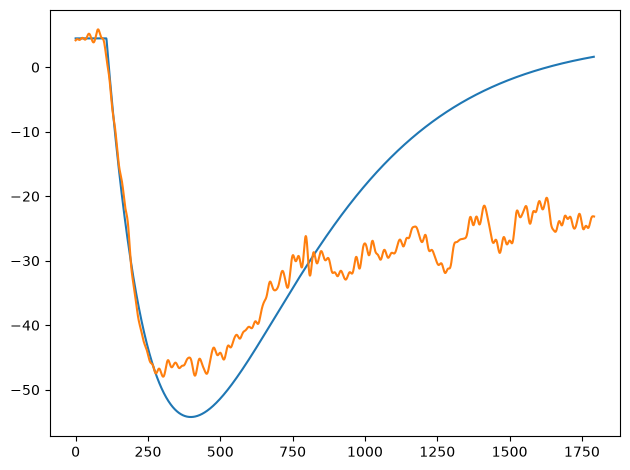

In [6]:
y = df[(df.condition_id=='DFT_6') & (df.category=='objet') & (df.valence=='neutre')]['RDX (pix)']
x = np.linspace(0, len(y), len(y))
values, fit = model_fit(len(y), y)
print(values)

plt.plot(fit)
plt.plot(x, y)
plt.tight_layout()